# Proyek Analisis Data: [Bike Sharing Analysis]
- **Nama:** [Muhammad Rifai]
- **Email:** [ahmadripai.wijaya04@gmail.com]
- **ID Dicoding:** [7729510]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Pada musim apa jumlah penyewaan sepeda paling tinggi?
- Pertanyaan 2 : Bagaimana pola penggunaan sepeda antara pelanggan casual dan registered dari waktu ke waktu?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# HAPUS: import streamlit as st  

## Data Wrangling

### Gathering Data

In [5]:
# Baca file sebagai teks
with open('Bike_sharing_dataset.csv', 'r') as f:
    lines = f.readlines()

# Bersihkan semua baris bermasalah
clean_lines = []
for line in lines:
    # Hapus conflict markers
    if line.startswith('<<<<<<<') or line.startswith('=======') or line.startswith('>>>>>>>'):
        continue
    # Hapus baris yang mengandung header duplikat
    if 'dteday' in line and 'instant' in line and clean_lines:
        continue
    clean_lines.append(line)

# Simpan file yang sudah bersih
with open('Bike_sharing_dataset_clean.csv', 'w') as f:
    f.writelines(clean_lines)

print("✅ File berhasil dibersihkan!")

# Load dataset bersih
import pandas as pd
df = pd.read_csv('Bike_sharing_dataset_clean.csv')
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("Dtypes:")
print(df.dtypes)
print(df.head())

✅ File berhasil dibersihkan!
Shape: (1462, 16)
Dtypes:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446  

### Assessing Data

In [6]:
print("== Shape Dataset ==")
print(df.shape)

print("\n== Info Dataset ==")
print(df.info())

print("\n== Missing Values ==")
print(df.isnull().sum())

print("\n== Data Duplikat ==")
print(df.duplicated().sum())

print("\n== Statistik Deskriptif ==")
print(df.describe())

== Shape Dataset ==
(1462, 16)

== Info Dataset ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     1462 non-null   int64  
 1   dteday      1462 non-null   object 
 2   season      1462 non-null   int64  
 3   yr          1462 non-null   int64  
 4   mnth        1462 non-null   int64  
 5   holiday     1462 non-null   int64  
 6   weekday     1462 non-null   int64  
 7   workingday  1462 non-null   int64  
 8   weathersit  1462 non-null   int64  
 9   temp        1462 non-null   float64
 10  atemp       1462 non-null   float64
 11  hum         1462 non-null   float64
 12  windspeed   1462 non-null   float64
 13  casual      1462 non-null   int64  
 14  registered  1462 non-null   int64  
 15  cnt         1462 non-null   int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 182.9+ KB
None

== Missing Values ==
instant     

### Cleaning Data

In [7]:
# Konversi kolom tanggal ke datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# Mapping kolom season
df['season_label'] = df['season'].map({
    1: 'Springer',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

print("✅ Data setelah cleaning:")
print(df[['dteday', 'season', 'season_label']].head())
print(df.dtypes)


✅ Data setelah cleaning:
      dteday  season season_label
0 2011-01-01       1     Springer
1 2011-01-02       1     Springer
2 2011-01-03       1     Springer
3 2011-01-04       1     Springer
4 2011-01-05       1     Springer
instant                  int64
dteday          datetime64[ns]
season                   int64
yr                       int64
mnth                     int64
holiday                  int64
weekday                  int64
workingday               int64
weathersit               int64
temp                   float64
atemp                  float64
hum                    float64
windspeed              float64
casual                   int64
registered               int64
cnt                      int64
season_label            object
dtype: object


In [13]:
# Hapus duplikat berdasarkan tanggal
df = df.drop_duplicates(subset=['dteday'], keep='first')

print("Shape setelah hapus duplikat:", df.shape)
# Harusnya (731, 16)

# Cek ulang total penyewaan per musim
season_counts = df.groupby('season_label')['cnt'].sum().reindex(
    ['Springer', 'Summer', 'Fall', 'Winter']
)
print(season_counts)

Shape setelah hapus duplikat: (731, 17)
season_label
Springer     471348
Summer       918589
Fall        1061129
Winter       841613
Name: cnt, dtype: int64


## Exploratory Data Analysis (EDA)

#### Explore Pertanyaan 1: Penyewaan per Musim

In [14]:
print("== Total Penyewaan per Musim ==")
season_counts = df.groupby('season_label')['cnt'].sum().reindex(
    ['Springer', 'Summer', 'Fall', 'Winter']
)
print(season_counts)

print("\n== Musim dengan Penyewaan Tertinggi ==")
print(season_counts.idxmax(), "-", season_counts.max())

== Total Penyewaan per Musim ==
season_label
Springer     471348
Summer       918589
Fall        1061129
Winter       841613
Name: cnt, dtype: int64

== Musim dengan Penyewaan Tertinggi ==
Fall - 1061129


#### Explore Pertanyaan 2: Pola Casual vs Registered

In [15]:
print("== Statistik Casual vs Registered ==")
print(df[['casual', 'registered']].describe())

print("\n== Total Casual vs Registered ==")
print("Total Casual    :", df['casual'].sum())
print("Total Registered:", df['registered'].sum())

== Statistik Casual vs Registered ==
            casual   registered
count   731.000000   731.000000
mean    848.176471  3656.172367
std     686.622488  1560.256377
min       2.000000    20.000000
25%     315.500000  2497.000000
50%     713.000000  3662.000000
75%    1096.000000  4776.500000
max    3410.000000  6946.000000

== Total Casual vs Registered ==
Total Casual    : 620017
Total Registered: 2672662


#### Explore Korelasi antar Variabel

In [16]:
print("== Korelasi Spearman ==")
corr = df[['temp', 'hum', 'windspeed', 'cnt']].corr(method='spearman')
print(corr)

== Korelasi Spearman ==
               temp       hum  windspeed       cnt
temp       1.000000  0.129903  -0.147153  0.622034
hum        0.129903  1.000000  -0.239006 -0.098126
windspeed -0.147153 -0.239006   1.000000 -0.217197
cnt        0.622034 -0.098126  -0.217197  1.000000


## Visualization & Explanatory Analysis

#### Visualisasi Pertanyaan 1: Bar Chart Penyewaan per Musim

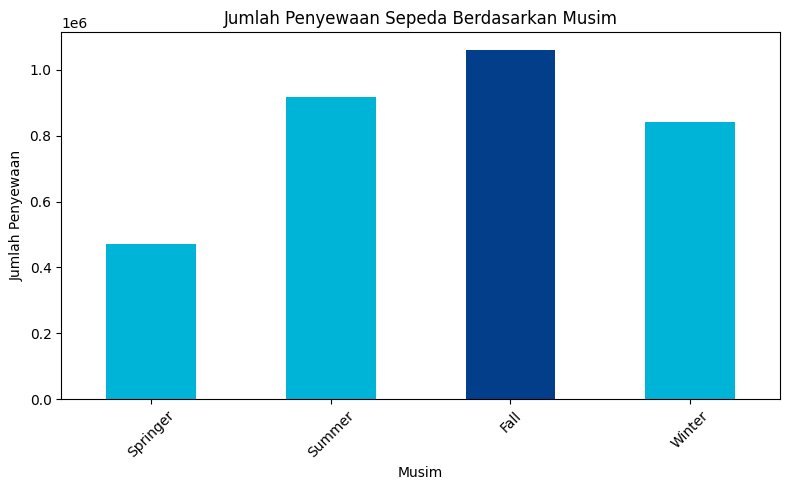

In [17]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
season_counts.plot(
    kind='bar',
    ax=ax1,
    color=['#00b4d8', '#00b4d8', '#023e8a', '#00b4d8']
)
ax1.set_xlabel('Musim')
ax1.set_ylabel('Jumlah Penyewaan')
ax1.set_title('Jumlah Penyewaan Sepeda Berdasarkan Musim')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()                   


#### Visualisasi Pertanyaan 2: Pola Casual vs Registered

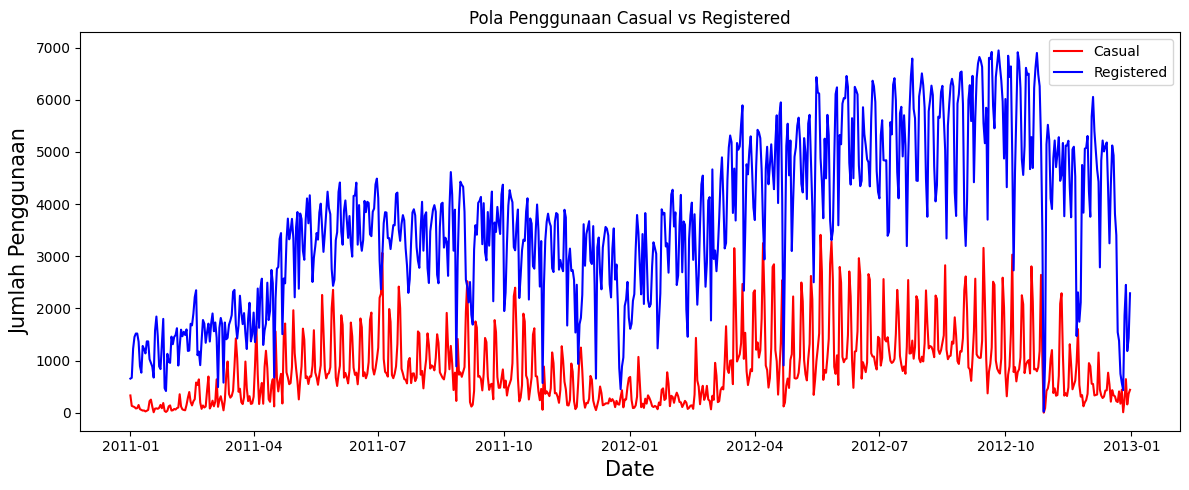

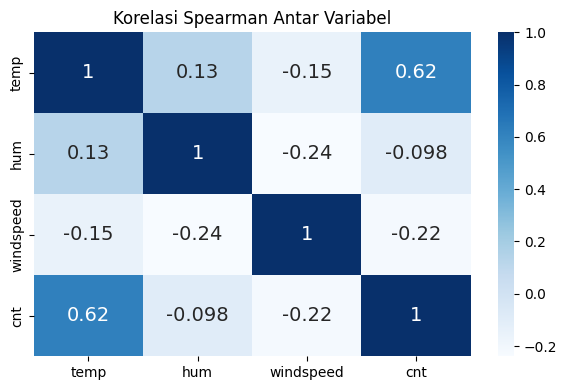

In [18]:
fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.plot(df['dteday'], df['casual'], label='Casual', color='red')
ax2.plot(df['dteday'], df['registered'], label='Registered', color='blue')
ax2.set_xlabel('Date', size=15)
ax2.set_ylabel('Jumlah Penggunaan', size=15)
ax2.set_title('Pola Penggunaan Casual vs Registered')
ax2.legend()
plt.tight_layout()
plt.show()

# ── Visualisasi Korelasi Spearman ─────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size': 14},
    cmap='Blues',
    ax=ax3
)
ax3.set_title('Korelasi Spearman Antar Variabel')
plt.tight_layout()
plt.show()                         

## Conclusion

── Conclusion Pertanyaan 1 ───────────────────────────────────────
Musim Fall (Gugur) memiliki jumlah penyewaan tertinggi dengan total 1.061.129 penyewaan, diikuti Summer, Winter, dan Springer. Hal ini menunjukkan bahwa cuaca yang tidak terlalu panas maupun dingin mendorong lebih banyak orang untuk menyewa sepeda.

── Conclusion Pertanyaan 2 ───────────────────────────────────────
Pelanggan registered secara konsisten mendominasi penggunaan sepeda dibanding casual di sepanjang waktu. Pelanggan casual cenderung meningkat pada musim tertentu (puncak di musim panas),sementara registered lebih stabil, mengindikasikan penggunaan rutin seperti commuting.